# Baseline

In [14]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.modeling.models import ConjRuleBaseline
from heart_failure.modeling.evaluate import get_metrics, log_metrics
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX
from heart_failure.config.features import (
    TEST_SIZE, RANDOM_STATE, CONJ_RULES, CONJ_MIN_MASK_COUNT, CONJ_MIN_TARGET_RATE, VAL_SIZE
)

In [15]:
MODEL_NAME = "conjunctive_rules_baseline"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

For the baseline, I'll use the feature I constructed earlier. This is simply a set of rules and their combinations (and/or) that I discovered from EDA. That is high Oldpeak, low MaxHR, etc.

Since the business problem is to detect heart failure, I want to capture as many diseases as possible, although accuracy may suffer. The classes are distributed almost evenly. For this task, I chose the following metrics:
- Recall (pay attention to this first)
- Precision (less important, but very poor values are also undesirable)
- F2-Score
- PR-AUC

In [16]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

stratify = df[[SEX, HEART_DISEASE]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify
)
val_stratify = [X_train[SEX], y_train]
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train
)

In [17]:
model = ConjRuleBaseline(CONJ_RULES, CONJ_MIN_MASK_COUNT, CONJ_MIN_TARGET_RATE)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Metrics

In [18]:
print("Train metrics")
train_metrics = get_metrics(y_train, y_train_pred)
train_metrics

Train metrics


precision    0.870027
recall       0.901099
f2_score     0.894708
dtype: float64

In [19]:
print("Test metrics")
test_metrics = get_metrics(y_test, y_test_pred)
test_metrics

Test metrics


precision    0.826087
recall       0.931373
f2_score     0.908222
dtype: float64

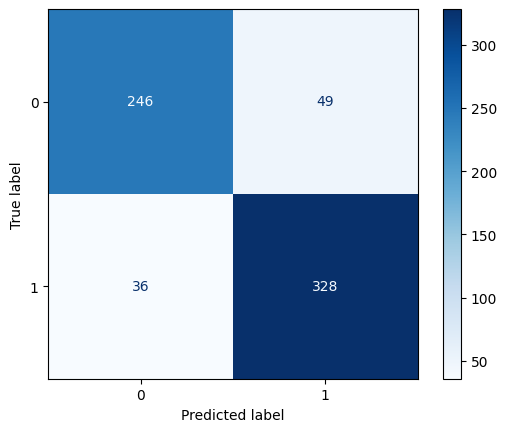

In [20]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap="Blues")
plt.show()

The predictions contain significant number of FN. However, this is the baseline. Let's write down the metrics. If any model performs worse on train than this one, it's not needed.



In [21]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_dict(CONJ_RULES, "rule_conditions.json")
    mlflow.log_param("conjunctive_min_count", CONJ_MIN_MASK_COUNT)
    mlflow.log_param("conjunctive_min_target_rate", CONJ_MIN_TARGET_RATE)

    log_metrics(train_metrics, "train_")
    log_metrics(test_metrics, "test_")